# Laboratorio 3: Redes neuronales convolucionales

- Mathew Cordero 22982
- Pedro Guzmán 22111

In [ ]:

# Esto solo en google colab
# # Instalaciones necesarias en colab e importaciones en colab

# from google.colab import drive
# drive.mount('/content/drive')
# !apt-get install unrar -y
# import os

# rar_path = "/content/drive/MyDrive/MMNIST/test.rar"
# output_dir = os.path.dirname(rar_path)  # Mismo directorio

# !unrar x -o+ "{rar_path}" "{output_dir}"




In [12]:

# Esto solo en google colab
# # Instalaciones necesarias en colab e importaciones en colab

# from google.colab import drive
# drive.mount('/content/drive')
# !apt-get install unrar -y
# import os

# rar_path = "/content/drive/MyDrive/MMNIST/train.rar"
# output_dir = os.path.dirname(rar_path)  # Mismo directorio

# !unrar x -o+ "{rar_path}" "{output_dir}"




Se truncaron las últimas líneas 5000 del resultado de transmisión.
Extracting  /content/drive/MyDrive/MMNIST/train/m4/6139.1.png             98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/6139.7.png             98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.0.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.1.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.2.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.3.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.4.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.5.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.6.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.7.png              98%  OK 
Extracting  /

## Análisis exploratorio

Primero empezaremos haciendo un análisis exploratorio sobre el conjunto de imágenes, obtendremos información de sus dimensiones, cuántas hay, que formatos tienen, etc.

In [9]:
import os
#import cv2
import pandas as pd
from PIL import Image

def analyze_dataset(base_path):
    data = []

    for subfolder in sorted(os.listdir(base_path)):
        subfolder_path = os.path.join(base_path, subfolder)

        if not os.path.isdir(subfolder_path):
            continue

        for file in os.listdir(subfolder_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(subfolder_path, file)
                size_kb = os.path.getsize(img_path) / 1024
                with Image.open(img_path) as img:
                    data.append({
                        "Carpeta": subfolder,
                        "Nombre": file,
                        "Formato": img.format,
                        "Ancho": img.width,
                        "Alto": img.height,
                        "Tamaño (KB)": size_kb
                    })
    return pd.DataFrame(data)


In [10]:
base_path = "/content/drive/MyDrive/MMNIST/test" # aqui agregar el path que necesitas yo como lo hago en colab asi lo pusimos
df = analyze_dataset(base_path)
df.head()  # Muestra las primeras filas


,Carpeta,Nombre,Formato,Ancho,Alto,Tamaño (KB)
0,m0,443.9.png,PNG,28,28,0.983398
1,m0,444.4.png,PNG,28,28,2.151367
2,m0,444.1.png,PNG,28,28,0.857422
3,m0,444.0.png,PNG,28,28,0.920898
4,m0,444.2.png,PNG,28,28,1.006836


In [14]:
print("Tamaño del DataFrame:", df.shape)  # Muestra (filas, columnas)


Tamaño del DataFrame: (50000, 6)


In [15]:
train_path = "/content/drive/MyDrive/MMNIST/train"
df_train = analyze_dataset(train_path)

print(f"🔹 Total de imágenes en TRAIN: {len(df_train)}")
df_train.groupby("Carpeta").size()

🔹 Total de imágenes en TRAIN: 300000


,0
Carpeta,
m0,60000
m1,60000
m2,60000
m3,60000
m4,60000


In [16]:
df_test = df

Ahora que generamos los datasets, los guardamos como csv

In [17]:
df_test.to_csv('test_images.csv', index=False)
df_train.to_csv('train_images.csv', index=False)

Ahora obtenemos un resumen inicial sobre las característcas iniciales.

In [18]:
df_test.describe()

,Ancho,Alto,Tamaño (KB)
count,50000.0,50000.0,50000.000000
mean,28.0,28.0,1.444386
std,0.0,0.0,0.387236
min,28.0,28.0,0.275391
25%,28.0,28.0,1.105469
50%,28.0,28.0,1.473633
75%,28.0,28.0,1.771484
max,28.0,28.0,2.318359


Todas las imágenes en el conjunto de prueba tienen las mismas dimensiones, sin embargo su tamaño en kb cambia, esto sugiere que tal vez las imágenes más pesadas tienen más colores y formas más complejas. Ahora veremos una pequeña muestra de las imágenes.

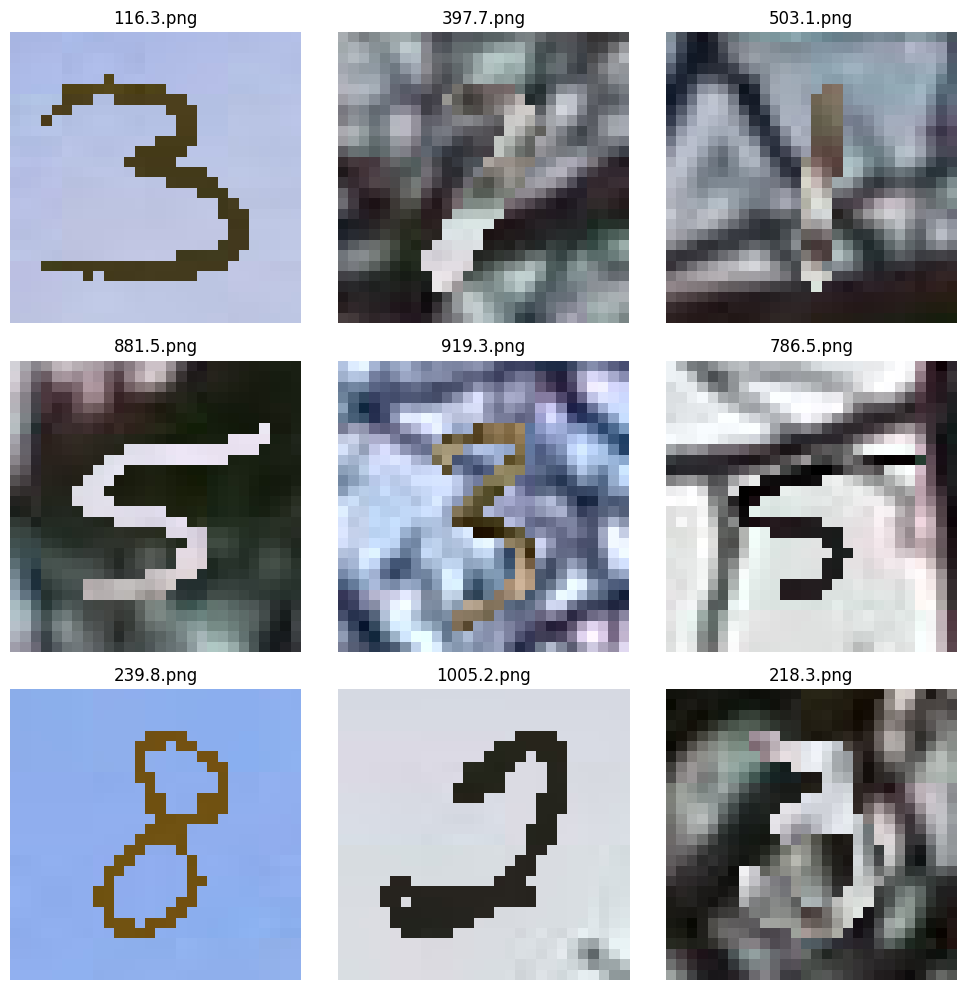

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os, random

folder = base_path + "/m0"
files = os.listdir(folder)
files = [f for f in files if f.endswith(".png")]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    file = random.choice(files)
    img = mpimg.imread(os.path.join(folder, file))
    plt.imshow(img, cmap="gray")
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()


Hay imágenes con más resolución que otras, esto confirma la razón de porque no todas tienen el mismo tamaño. Ahora vamos con las de train

In [21]:
df_train.describe()

,Ancho,Alto,Tamaño (KB)
count,300000.0,300000.0,300000.000000
mean,28.0,28.0,1.443726
std,0.0,0.0,0.387686
min,28.0,28.0,0.250000
25%,28.0,28.0,1.104492
50%,28.0,28.0,1.473633
75%,28.0,28.0,1.769531
max,28.0,28.0,2.301758


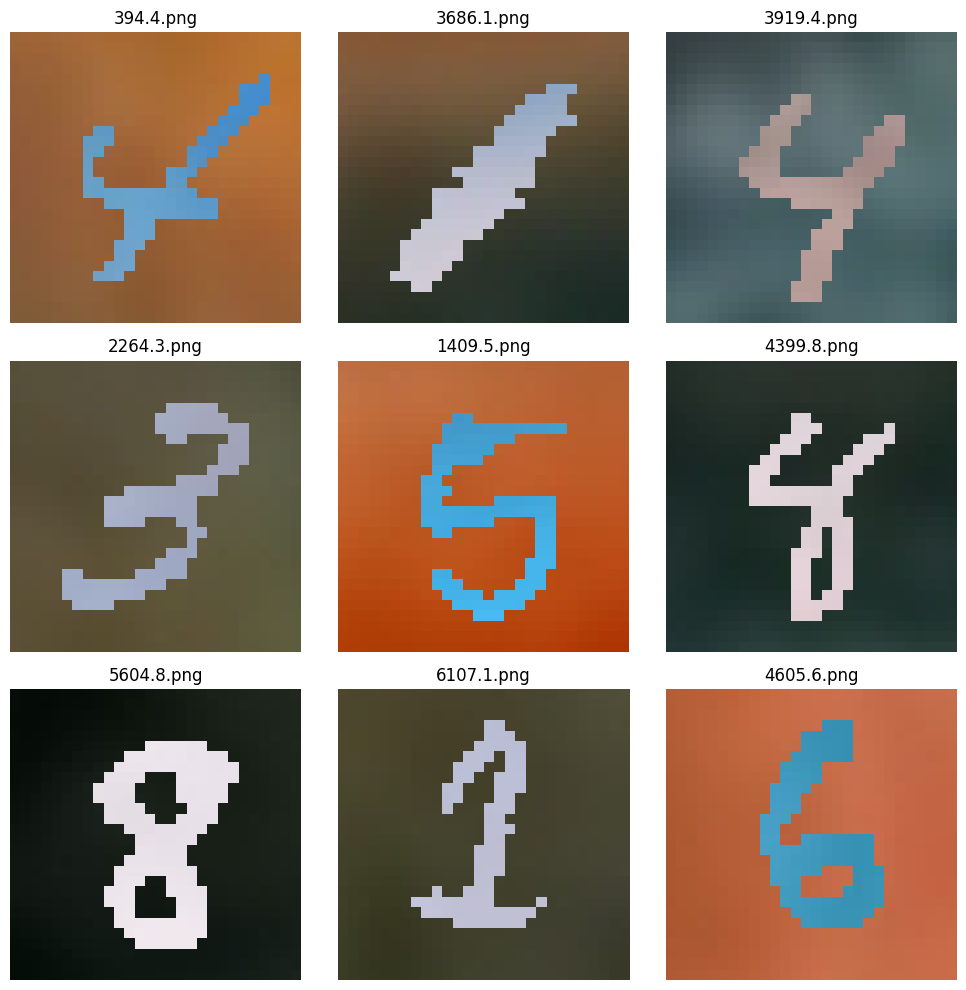

In [24]:
folder = train_path + "/m1"
files = os.listdir(folder)
files = [f for f in files if f.endswith(".png")]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    file = random.choice(files)
    img = mpimg.imread(os.path.join(folder, file))
    plt.imshow(img, cmap="gray")
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Preprocesamiento de Imagenes

Vimos que algunas imágenes tienen una ligera rotación por lo que a cada una le aplicaremos también una pequeña rotación de 15 grados, otra cosas que haremos es convertir todo a escala de grises y normalizar.

In [29]:

# Esto solo sirve en google colab
# import os
# import shutil
# from tqdm import tqdm

# def copy_with_progress(src_dir, dst_dir):
#     os.makedirs(dst_dir, exist_ok=True)

#     # Contar cuántos archivos hay
#     all_files = []
#     for root, _, files in os.walk(src_dir):
#         for f in files:
#             src_file = os.path.join(root, f)
#             rel_path = os.path.relpath(src_file, src_dir)
#             dst_file = os.path.join(dst_dir, rel_path)
#             all_files.append((src_file, dst_file))

#     for src_file, dst_file in tqdm(all_files, desc=f"Copiando {src_dir}", unit="archivo"):
#         os.makedirs(os.path.dirname(dst_file), exist_ok=True)
#         shutil.copy2(src_file, dst_file)

# # 🔄 Usar
# copy_with_progress("/content/drive/MyDrive/MMNIST/test",  "/content/test")
# copy_with_progress("/content/drive/MyDrive/MMNIST/train", "/content/train")


Copiando /content/drive/MyDrive/MMNIST/train: 100%|██████████| 300000/300000 [25:59<00:00, 192.43archivo/s]


In [30]:
import os
import tensorflow as tf
from tqdm import tqdm

def process_dataset_tf(input_path, output_path):
    os.makedirs(output_path, exist_ok=True)

    for folder in os.listdir(input_path):  # m0, m1, m2, ...
        input_folder = os.path.join(input_path, folder)
        if not os.path.isdir(input_folder):
            continue

        for file in tqdm(os.listdir(input_folder), desc=f"Procesando {folder}"):
            if not file.endswith(".png"):
                continue

            try:
                class_label = file.split(".")[1]  # "31.0.png" -> "0"
            except IndexError:
                continue

            label_folder = os.path.join(output_path, class_label)
            os.makedirs(label_folder, exist_ok=True)

            # Leer imagen como tensor
            img_path = os.path.join(input_folder, file)
            try:
                image_raw = tf.io.read_file(img_path)
                image_tensor = tf.image.decode_png(image_raw, channels=3)

                # Convertir a escala de grises y redimensionar (en GPU si está disponible)
                gray = tf.image.rgb_to_grayscale(image_tensor)
                resized = tf.image.resize(gray, [28, 28])

                # Convertir tensor a PNG nuevamente
                resized_uint8 = tf.cast(resized, tf.uint8)
                encoded = tf.io.encode_png(resized_uint8)

                # Guardar imagen
                out_path = os.path.join(label_folder, file)
                tf.io.write_file(out_path, encoded)
            except Exception as e:
                print(f"❌ Error al procesar {file}: {e}")

# 📂 Paths
train_path = "/content/train"
test_path  = "/content/test"

output_train = "images/train_gray_sorted_tf"
output_test  = "images/test_gray_sorted_tf"

# 🚀 Ejecutar
process_dataset_tf(train_path, output_train)
process_dataset_tf(test_path, output_test)

print("✅ Procesamiento con TensorFlow terminado.")


Procesando m0: 100%|██████████| 10000/10000 [00:48<00:00, 207.00it/s]

✅ Procesamiento con TensorFlow terminado.


In [3]:
import tensorflow as tf

# Lista las GPUs disponibles
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ GPU detectada:")
    for gpu in gpus:
        print(f" - {gpu}")
else:
    print("❌ No se detectó GPU")

# Verifica si TensorFlow está usando la GPU por defecto
print("\nDispositivo en uso:")
print(tf.test.gpu_device_name())

❌ No se detectó GPU

Dispositivo en uso:



AHora los cargamos en tensorflow, ya que nos servira para entrenar los modelos

In [63]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "images/train_gray_sorted",
    image_size=(28,28),
    color_mode='grayscale',
    batch_size=512,
    label_mode='int'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "images/test_gray_sorted",
    image_size=(28,28),
    color_mode='grayscale',
    batch_size=512,
    label_mode='int'
)


Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


Ahora normalizaremos a pixeles, esto sirve para poner en rangos de 0s y 1s . Este un ejemplo de como seria

In [64]:
import tensorflow as tf
import matplotlib.pyplot as plt


img_path = "/content/images/train_gray_sorted_tf/0/31.0.png"  # pon aquí una ruta válida en tu disco


image_raw = tf.io.read_file(img_path)
image = tf.image.decode_png(image_raw, channels=1)  # escala de grises


plt.subplot(1, 2, 1)
plt.title("Original (0-255)")
plt.imshow(tf.squeeze(image), cmap='gray')
plt.colorbar()


normalization_layer = tf.keras.layers.Rescaling(1./255)
image_norm = normalization_layer(image)


plt.subplot(1, 2, 2)
plt.title("Normalizada (0-1)")
plt.imshow(tf.squeeze(image_norm), cmap='gray')
plt.colorbar()

plt.show()


NotFoundError: {{function_node __wrapped__ReadFile_device_/job:localhost/replica:0/task:0/device:CPU:0}} NewRandomAccessFile failed to Create/Open: /content/images/train_gray_sorted_tf/0/31.0.png : El sistema no puede encontrar la ruta especificada.
; No such process [Op:ReadFile]

Ahora si normalizamos todas

In [65]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Y aqui dividimos en validacion y testeo

In [66]:
# Cantidad total de batches en test_ds
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

# 20% para validación, 80% para test
val_batches = int(test_batches * 0.2)
test_batches_final = test_batches - val_batches

# Crear validación y test final con take y skip
val_ds = test_ds.take(val_batches)
test_ds_final = test_ds.skip(val_batches)


# *Modelos*

Lo que vamos a hacer antes de todo esto, es ejecutarlo en coolab ya que no tenemos GPU y nos permite usar la memoria extendida. Asi que al cambiar el entorno de ejecucion damos esto

## Modelos sin Transformaciones

Aqui haremos los 3 modelos para CNN sin aplicar data aumentation, solo como vienen

### CNN simple

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

def modelo_simple_sin_augmentation():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


### CNN batch normalization y dropout

In [12]:
def modelo_intermedio_sin_augmentation():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=(28,28,1)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


### CNN arquitectura VGG

In [13]:
  import tensorflow as tf
  from tensorflow.keras import layers, models

  def modelo_vgg_like():
      model = models.Sequential([
          # Bloque 1
          layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)),
          layers.Conv2D(32, (3,3), padding='same', activation='relu'),
          layers.MaxPooling2D((2,2)),
          layers.Dropout(0.25),

          # Bloque 2
          layers.Conv2D(64, (3,3), padding='same', activation='relu'),
          layers.Conv2D(64, (3,3), padding='same', activation='relu'),
          layers.MaxPooling2D((2,2)),
          layers.Dropout(0.25),

          # Bloque 3
          layers.Conv2D(128, (3,3), padding='same', activation='relu'),
          layers.Conv2D(128, (3,3), padding='same', activation='relu'),
          layers.MaxPooling2D((2,2)),
          layers.Dropout(0.25),

          layers.Flatten(),
          layers.Dense(512, activation='relu'),
          layers.Dropout(0.5),
          layers.Dense(10, activation='softmax')  # 10 clases
      ])

      model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
      return model


## Los entrenamos y probamos

### Modelo 1

In [14]:
model_1 = modelo_vgg_like()

history_1 = model_1.fit(train_ds,
                    validation_data=val_ds,
                    epochs=20)

Epoch 1/20


c:\Users\ppguz\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


118/118 ━━━━━━━━━━━━━━━━━━━━ 28s 230ms/step - accuracy: 0.3453 - loss: 1.7828 - val_accuracy: 0.8540 - val_loss: 0.4301
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 24s 204ms/step - accuracy: 0.8698 - loss: 0.4061 - val_accuracy: 0.9341 - val_loss: 0.2143
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.9237 - loss: 0.2425 - val_accuracy: 0.9536 - val_loss: 0.1453
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.9410 - loss: 0.1844 - val_accuracy: 0.9702 - val_loss: 0.0977
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 164ms/step - accuracy: 0.9516 - loss: 0.1509 - val_accuracy: 0.9653 - val_loss: 0.1052
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 57s 481ms/step - accuracy: 0.9572 - loss: 0.1305 - val_accuracy: 0.9688 - val_loss: 0.0935
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 40s 333ms/step - accuracy: 0.9628 - loss: 0.1145 - val_accuracy: 0.9727 - val_loss: 0.0924
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 28s 235ms/step - accuracy: 0.9686 - loss: 0.0970 - val

Vemos su desempeño

In [15]:
test_loss_1, test_accuracy_1 = model_1.evaluate(test_ds)
print(f"Test Loss: {test_loss_1:.4f}")
print(f"Test Accuracy: {test_accuracy_1:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9840 - loss: 0.0528
Test Loss: 0.0609
Test Accuracy: 0.9823


### Modelo 2

In [16]:
model_2 = modelo_simple_sin_augmentation()

history_2 = model_2.fit(train_ds,
                    validation_data=val_ds,
                    epochs=20)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.4340 - loss: 1.6786 - val_accuracy: 0.7461 - val_loss: 0.8074
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.8348 - loss: 0.5777 - val_accuracy: 0.8389 - val_loss: 0.5213
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.8896 - loss: 0.4099 - val_accuracy: 0.8716 - val_loss: 0.4276
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.9054 - loss: 0.3399 - val_accuracy: 0.8906 - val_loss: 0.3694
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.9201 - loss: 0.2912 - val_accuracy: 0.8940 - val_loss: 0.3378
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.9295 - loss: 0.2560 - val_accuracy: 0.9131 - val_loss: 0.2802
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - accuracy: 0.9365 - loss: 0.2293 - val_accuracy: 0.9116 - val_loss: 0.2843
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 168ms/step - accuracy: 0.9430 - loss: 0.2052 - val_

In [17]:
test_loss_2, test_accuracy_2 = model_2.evaluate(test_ds)
print(f"Test Loss: {test_loss_2:.4f}")
print(f"Test Accuracy: {test_accuracy_2:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9352 - loss: 0.2247
Test Loss: 0.2320
Test Accuracy: 0.9342


### Modelo 3

In [18]:
model_3 = modelo_intermedio_sin_augmentation()

history_3 = model_3.fit(train_ds,
                    validation_data=val_ds,
                    epochs=20)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.1951 - loss: 2.6463 - val_accuracy: 0.2715 - val_loss: 2.1692
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.5672 - loss: 1.2239 - val_accuracy: 0.6934 - val_loss: 1.6423
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 15s 128ms/step - accuracy: 0.6656 - loss: 0.9528 - val_accuracy: 0.7324 - val_loss: 1.1493
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 131ms/step - accuracy: 0.7053 - loss: 0.8390 - val_accuracy: 0.7598 - val_loss: 0.8327
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - accuracy: 0.7328 - loss: 0.7750 - val_accuracy: 0.8003 - val_loss: 0.6139
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - accuracy: 0.7525 - loss: 0.7184 - val_accuracy: 0.8843 - val_loss: 0.4072
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 15s 129ms/step - accuracy: 0.7622 - loss: 0.6890 - val_accuracy: 0.8203 - val_loss: 0.5549
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 15s 129ms/step - accuracy: 0.7706 - loss: 0

In [19]:
test_loss_3, test_accuracy_3 = model_3.evaluate(test_ds)
print(f"Test Loss: {test_loss_3:.4f}")
print(f"Test Accuracy: {test_accuracy_3:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8977 - loss: 0.3271
Test Loss: 0.3306
Test Accuracy: 0.9006


## Graficamos su desempeño

### Desempeño Modelo 1 CNN

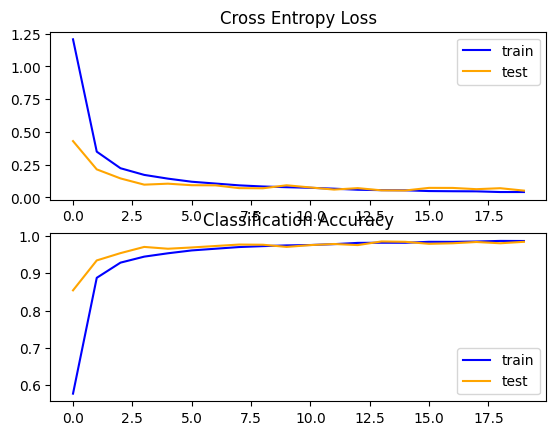

In [22]:
import matplotlib.pyplot as plt

plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history_1.history['loss'], color='blue', label='train')
plt.plot(history_1.history['val_loss'], color='orange', label='test')
plt.legend()
 # plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history_1.history['accuracy'], color='blue', label='train')
plt.plot(history_1.history['val_accuracy'], color='orange', label='test')
plt.legend()



###  Desempeño Modelo 2 CNN Simple

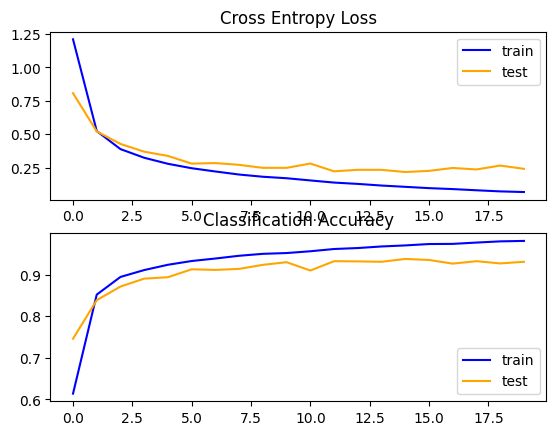

In [23]:
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history_2.history['loss'], color='blue', label='train')
plt.plot(history_2.history['val_loss'], color='orange', label='test')
plt.legend()
 # plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history_2.history['accuracy'], color='blue', label='train')
plt.plot(history_2.history['val_accuracy'], color='orange', label='test')
plt.legend()



### Desempeño Modelo 3 CNN con Dropout y Batch Normalization

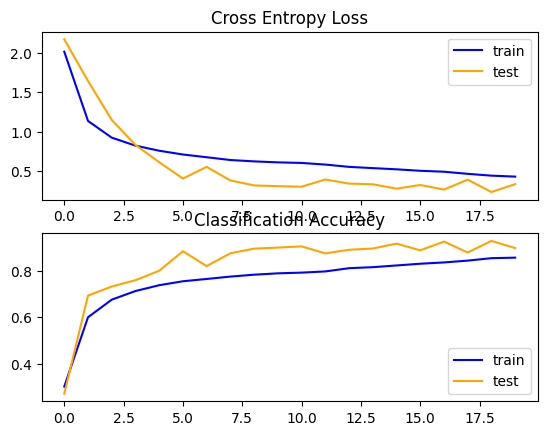

In [24]:
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history_3.history['loss'], color='blue', label='train')
plt.plot(history_3.history['val_loss'], color='orange', label='test')
plt.legend()
 # plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history_3.history['accuracy'], color='blue', label='train')
plt.plot(history_3.history['val_accuracy'], color='orange', label='test')
plt.legend()



## Red neuronal convencional

Ahora vamos a usar una red neuronal convencional para hacer un nuevo modelo, las entradas 

In [54]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "images/train_gray_sorted",
    image_size=(28, 28),  # Redimensionar a 28x28
    color_mode="grayscale",  # Si son imágenes en blanco y negro
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "images/test_gray_sorted",
    image_size=(28, 28),  # Redimensionar a 28x28
    color_mode="grayscale",  # Si son imágenes en blanco y negro
    batch_size=32
)



Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


In [55]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

test_batches = tf.data.experimental.cardinality(test_ds).numpy()

# 20% para validación, 80% para test
val_batches = int(test_batches * 0.2)
test_batches_final = test_batches - val_batches

# Crear validación y test final con take y skip
val_ds = test_ds.take(val_batches)
test_ds_final = test_ds.skip(val_batches)

In [56]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

train_ds = train_ds.map(lambda x, y: (tf.reshape(x/255.0, [-1, 28*28]), y))
val_ds = val_ds.map(lambda x, y: (tf.reshape(x/255.0, [-1, 28*28]), y))

model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),  # Capa oculta 1
    Dense(64, activation="relu"),                       # Capa oculta 2
    Dense(10, activation="softmax")                     # Capa de salida (10 clases)
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # porque las etiquetas son números 0-9
    metrics=["accuracy"]
)


c:\Users\ppguz\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
neural_net_history = model.fit(train_ds, validation_data=val_ds, epochs=30)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1451 - loss: 2.2499 - val_accuracy: 0.1648 - val_loss: 2.2209
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3761 - loss: 1.7849 - val_accuracy: 0.2349 - val_loss: 2.0563
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4487 - loss: 1.5938 - val_accuracy: 0.2742 - val_loss: 2.0148
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.4894 - loss: 1.5128 - val_accuracy: 0.3266 - val_loss: 1.9413
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5290 - loss: 1.4271 - val_accuracy: 0.3634 - val_loss: 1.8573
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5642 - loss: 1.3533 - val_accuracy: 0.3942 - val_loss: 1.8043
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.5822 - loss: 1.2948 - val_accuracy: 0.4042 - val_loss: 1.7438
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.5968 - loss: 1.2493

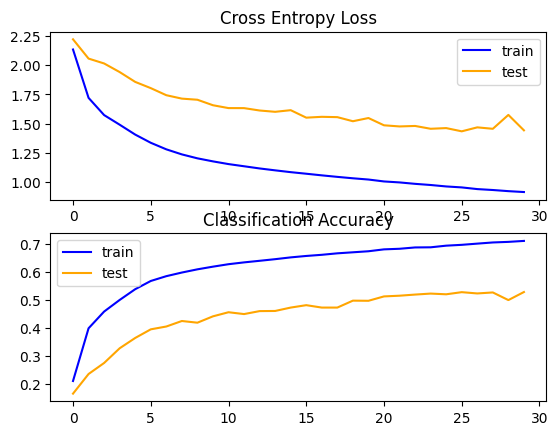

In [58]:
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(neural_net_history.history['loss'], color='blue', label='train')
plt.plot(neural_net_history.history['val_loss'], color='orange', label='test')
plt.legend()
 # plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(neural_net_history.history['accuracy'], color='blue', label='train')
plt.plot(neural_net_history.history['val_accuracy'], color='orange', label='test')
plt.legend()

In [34]:
import tensorflow as tf
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def prepare_data_for_knn(dataset):
    """
    Convierte el dataset de TensorFlow a arrays numpy para KNN
    """
    images = []
    labels = []
    
    print("Procesando imágenes...")
    batch_count = 0
    
    for image_batch, label_batch in dataset:
        batch_count += 1
        print(f"Procesando batch {batch_count}...")
        
        # Convertir batch a numpy
        images_np = image_batch.numpy()
        labels_np = label_batch.numpy()
        
        # Aplanar las imágenes (28,28,1) -> (784,)
        images_flattened = images_np.reshape(images_np.shape[0], -1)
        
        # Normalizar a rango 0-1
        images_flattened = images_flattened.astype(np.float32) / 255.0
        
        images.extend(images_flattened)
        labels.extend(labels_np)
    
    return np.array(images), np.array(labels)

def create_knn_model(n_neighbors=5, weights='uniform', metric='euclidean'):
    """
    Crea el modelo K-Nearest Neighbors
    """
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        metric=metric,
        n_jobs=-1  # Usar todos los procesadores disponibles
    )
    return model

def train_and_evaluate_knn(train_ds, test_ds, n_neighbors=5):
    """
    Entrena y evalúa el modelo KNN
    """
    print("Preparando datos de entrenamiento...")
    X_train, y_train = prepare_data_for_knn(train_ds)
    
    print("Preparando datos de prueba...")
    X_test, y_test = prepare_data_for_knn(test_ds)
    
    print(f"Forma de datos de entrenamiento: {X_train.shape}")
    print(f"Forma de datos de prueba: {X_test.shape}")
    print(f"Número de clases: {len(np.unique(y_train))}")
    
    # Crear modelo KNN
    print(f"Creando modelo KNN con k={n_neighbors}...")
    knn_model = create_knn_model(n_neighbors=n_neighbors)
    
    # Entrenar modelo
    print("Entrenando modelo KNN...")
    knn_model.fit(X_train, y_train)
    
    # Hacer predicciones
    print("Realizando predicciones...")
    y_pred = knn_model.predict(X_test)
    
    # Evaluar modelo
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nPrecisión del modelo: {accuracy:.4f}")
    
    # Reporte detallado
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))
    
    return knn_model, accuracy, y_test, y_pred

def plot_confusion_matrix(y_true, y_pred, title="Matriz de Confusión"):
    """
    Grafica la matriz de confusión
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(10), yticklabels=range(10))
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Verdadero')
    plt.show()

def optimize_k(train_ds, test_ds, k_range=range(1, 11)):
    """
    Encuentra el mejor valor de k probando diferentes opciones
    """
    print("Preparando datos para optimización...")
    X_train, y_train = prepare_data_for_knn(train_ds)
    X_test, y_test = prepare_data_for_knn(test_ds)
    
    best_k = 1
    best_accuracy = 0
    results = []
    
    print("Probando diferentes valores de k...")
    for k in k_range:
        print(f"Probando k={k}...")
        knn = create_knn_model(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        results.append((k, accuracy))
        print(f"k={k}, Precisión: {accuracy:.4f}")
        
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_k = k
    
    print(f"\nMejor k: {best_k} con precisión: {best_accuracy:.4f}")
    
    # Graficar resultados
    k_values, accuracies = zip(*results)
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, accuracies, 'bo-')
    plt.xlabel('Valor de k')
    plt.ylabel('Precisión')
    plt.title('Precisión vs Valor de k')
    plt.grid(True)
    plt.show()
    
    return best_k, results

def test_different_metrics(train_ds, test_ds, k=5):
    """
    Prueba diferentes métricas de distancia
    """
    print("Preparando datos...")
    X_train, y_train = prepare_data_for_knn(train_ds)
    X_test, y_test = prepare_data_for_knn(test_ds)
    
    metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
    results = []
    
    for metric in metrics:
        print(f"Probando métrica: {metric}")
        knn = create_knn_model(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results.append((metric, accuracy))
        print(f"Métrica {metric}: {accuracy:.4f}")
    
    # Encontrar la mejor métrica
    best_metric, best_accuracy = max(results, key=lambda x: x[1])
    print(f"\nMejor métrica: {best_metric} con precisión: {best_accuracy:.4f}")
    
    return best_metric, results

def predict_single_image(model, image, actual_label=None):
    """
    Predice una sola imagen
    """
    # Aplanar y normalizar la imagen
    image_flattened = image.reshape(1, -1).astype(np.float32) / 255.0
    
    # Hacer predicción
    prediction = model.predict(image_flattened)[0]
    
    # Obtener probabilidades (distancias)
    distances, indices = model.kneighbors(image_flattened)
    
    print(f"Predicción: {prediction}")
    if actual_label is not None:
        print(f"Etiqueta real: {actual_label}")
        print(f"Correcto: {'Sí' if prediction == actual_label else 'No'}")
    
    return prediction





In [45]:
knn_model, accuracy, y_test, y_pred = train_and_evaluate_knn(train_ds, test_ds, n_neighbors=80)




Preparando datos de entrenamiento...
Procesando imágenes...
Procesando batch 1...
Procesando batch 2...
Procesando batch 3...
Procesando batch 4...
Procesando batch 5...
Procesando batch 6...
Procesando batch 7...
Procesando batch 8...
Procesando batch 9...
Procesando batch 10...
Procesando batch 11...
Procesando batch 12...
Procesando batch 13...
Procesando batch 14...
Procesando batch 15...
Procesando batch 16...
Procesando batch 17...
Procesando batch 18...
Procesando batch 19...
Procesando batch 20...
Procesando batch 21...
Procesando batch 22...
Procesando batch 23...
Procesando batch 24...
Procesando batch 25...
Procesando batch 26...
Procesando batch 27...
Procesando batch 28...
Procesando batch 29...
Procesando batch 30...
Procesando batch 31...
Procesando batch 32...
Procesando batch 33...
Procesando batch 34...
Procesando batch 35...
Procesando batch 36...
Procesando batch 37...
Procesando batch 38...
Procesando batch 39...
Procesando batch 40...
Procesando batch 41...
Proces

## Transformación

Ahora aaplicamos otras tranformaciones a las imágenes:

- Una rotación aleatoria de 10 grados
- Un zoom aleatorio del 1%
- Un corte aleatorio en la imagen

In [61]:
def modelo_intermedio_con_augmentation():
    model = models.Sequential([
        # Data augmentation
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomCrop(28, 28),

        layers.Conv2D(32, (3,3), padding='same', input_shape=(28,28,1)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model



def modelo_intermedio_con_augmentation():
    model = models.Sequential([
        # Data augmentation
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomCrop(28, 28),

        layers.Conv2D(32, (3,3), padding='same', input_shape=(28,28,1)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def modelo_vgg_like_con_augmentation():
    model = models.Sequential([
        # Data augmentation
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomCrop(28, 28),

        # Bloque 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Bloque 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Bloque 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 27s 220ms/step - accuracy: 0.2991 - loss: 1.8958 - val_accuracy: 0.8540 - val_loss: 0.4395
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 62s 519ms/step - accuracy: 0.8597 - loss: 0.4308 - val_accuracy: 0.9194 - val_loss: 0.2409
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 19s 156ms/step - accuracy: 0.9164 - loss: 0.2585 - val_accuracy: 0.9497 - val_loss: 0.1511
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 19s 161ms/step - accuracy: 0.9396 - loss: 0.1878 - val_accuracy: 0.9639 - val_loss: 0.1085
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 44s 377ms/step - accuracy: 0.9523 - loss: 0.1465 - val_accuracy: 0.9644 - val_loss: 0.1028
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 172ms/step - accuracy: 0.9565 - loss: 0.1327 - val_accuracy: 0.9707 - val_loss: 0.0871
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 48s 411ms/step - accuracy: 0.9655 - loss: 0.1098 - val_accuracy: 0.9771 - val_loss: 0.0717
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.9674 - loss: 0

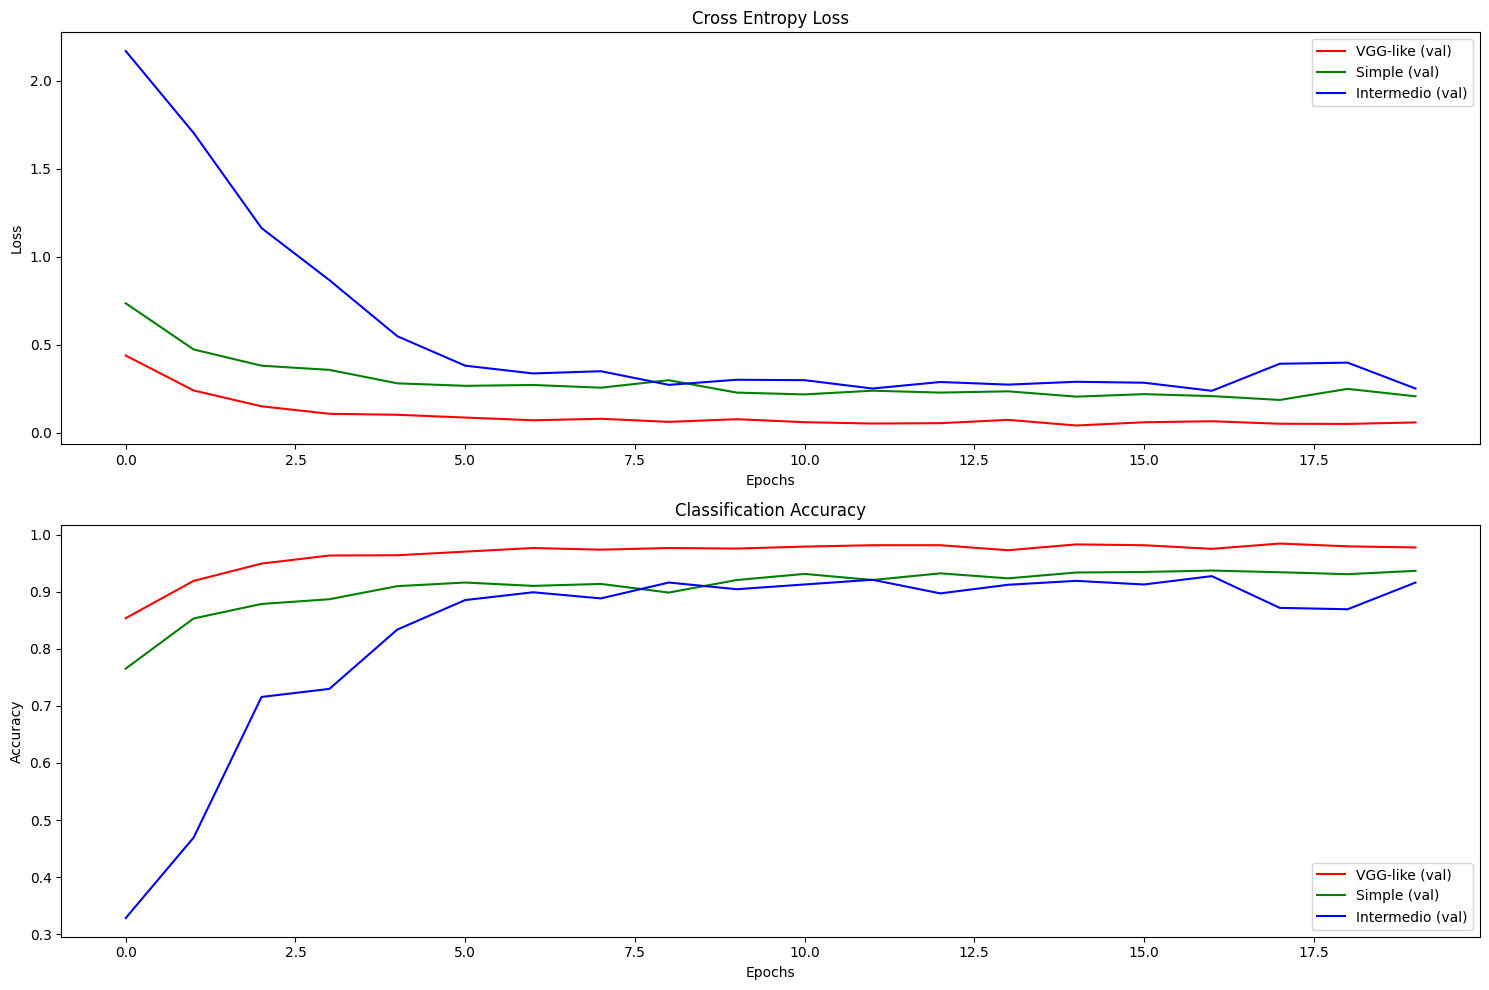

In [67]:
# Modelo 1: VGG-like
model_1 = modelo_vgg_like()
history_1 = model_1.fit(train_ds, validation_data=val_ds, epochs=20)
test_loss_1, test_accuracy_1 = model_1.evaluate(test_ds)
print(f"[Modelo 1 - VGG-like] Test Loss: {test_loss_1:.4f}, Test Accuracy: {test_accuracy_1:.4f}")

# Modelo 2: Simple
model_2 = modelo_simple_sin_augmentation()
history_2 = model_2.fit(train_ds, validation_data=val_ds, epochs=20)
test_loss_2, test_accuracy_2 = model_2.evaluate(test_ds)
print(f"[Modelo 2 - Simple] Test Loss: {test_loss_2:.4f}, Test Accuracy: {test_accuracy_2:.4f}")

# Modelo 3: Intermedio
model_3 = modelo_intermedio_sin_augmentation()
history_3 = model_3.fit(train_ds, validation_data=val_ds, epochs=20)
test_loss_3, test_accuracy_3 = model_3.evaluate(test_ds)
print(f"[Modelo 3 - Intermedio] Test Loss: {test_loss_3:.4f}, Test Accuracy: {test_accuracy_3:.4f}")


# ================== Gráficas ==================
plt.figure(figsize=(15,10))

# -------- Loss --------
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history_1.history['val_loss'], label='VGG-like (val)', color='red')
plt.plot(history_2.history['val_loss'], label='Simple (val)', color='green')
plt.plot(history_3.history['val_loss'], label='Intermedio (val)', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# -------- Accuracy --------
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history_1.history['val_accuracy'], label='VGG-like (val)', color='red')
plt.plot(history_2.history['val_accuracy'], label='Simple (val)', color='green')
plt.plot(history_3.history['val_accuracy'], label='Intermedio (val)', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Con esto podemos observa que el modelo VGG con la trasnformación aplicada fue el que mejor rendimiento tuvo, por lo tanto usaremos este modelo para calificar números hechos por nosotros mismos. 

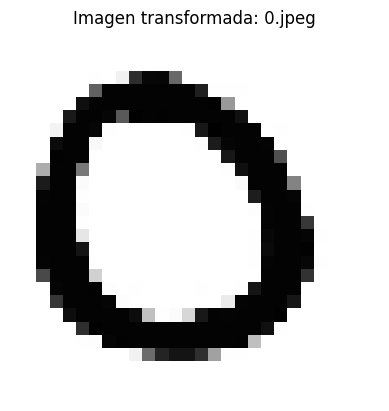

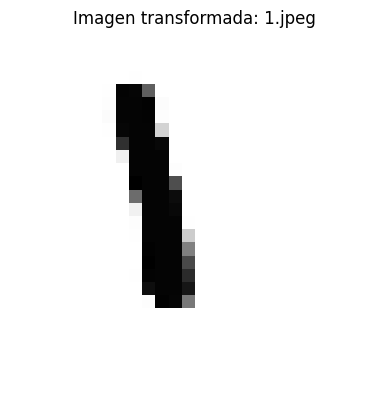

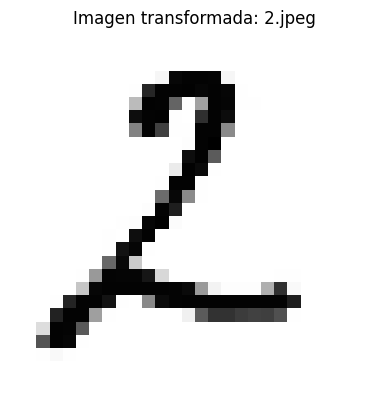

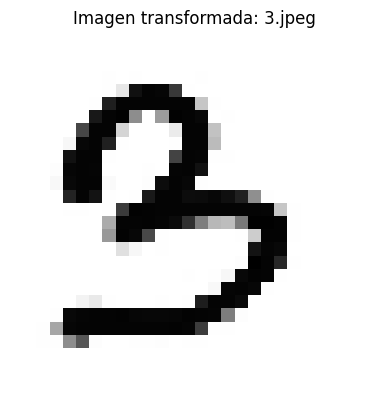

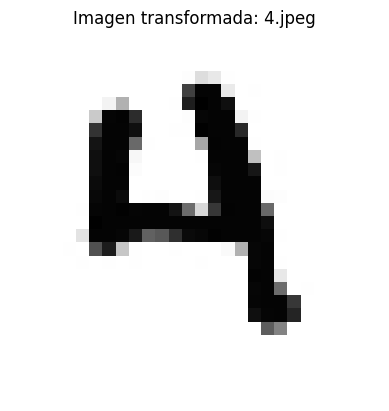

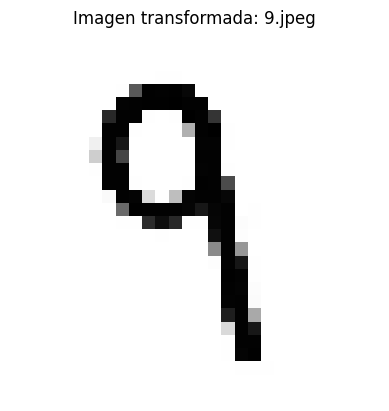

In [68]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt

carpeta_pruebas = "Pruebas_Amano"

for nombre in os.listdir(carpeta_pruebas):
    ruta = os.path.join(carpeta_pruebas, nombre)
    
    if not nombre.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        continue
    
    img = tf.keras.utils.load_img(ruta, color_mode='grayscale', target_size=(28,28))
    img_array = tf.keras.utils.img_to_array(img) / 255.0


    plt.imshow(img_array.squeeze(), cmap='gray')
    plt.title(f"Imagen transformada: {nombre}")
    plt.axis('off')
    plt.show()

Ahora vamos a usar el modelo para predecir.


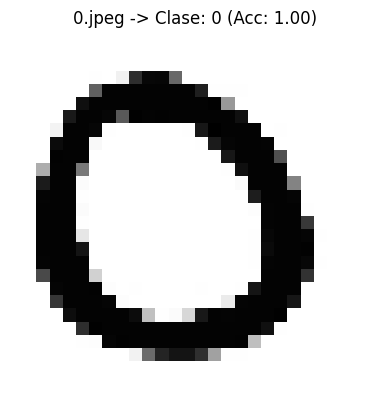

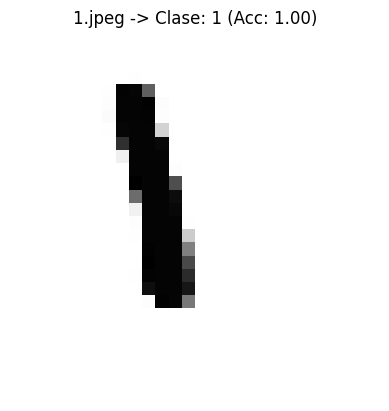

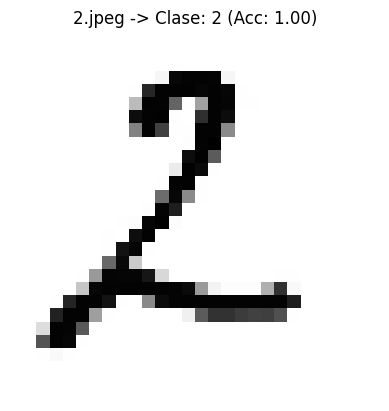

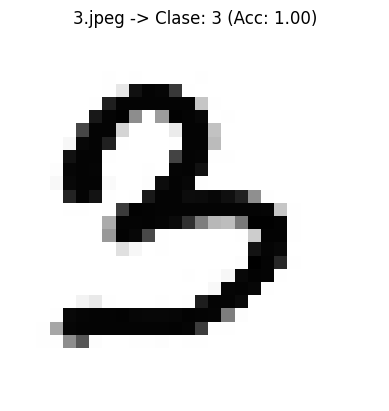

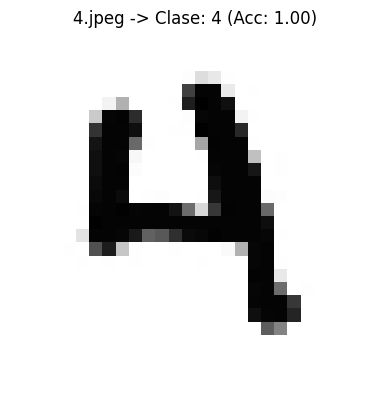

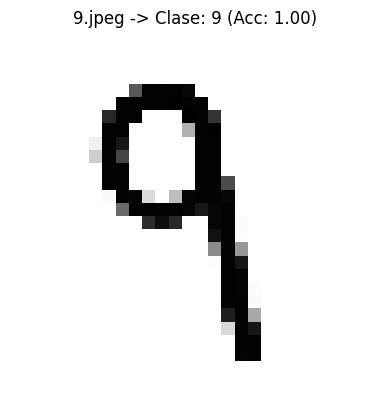

In [69]:
for nombre in os.listdir(carpeta_pruebas):
    ruta = os.path.join(carpeta_pruebas, nombre)
    
    if not nombre.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        continue
    

    img = tf.keras.utils.load_img(ruta, color_mode='grayscale', target_size=(28,28))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

   
    pred = model_1.predict(img_array, verbose=0)
    clase = np.argmax(pred)
    prob = pred[0][clase]

    # Mostrar imagen con etiqueta y accuracy
    plt.imshow(img_array[0].squeeze(), cmap='gray')
    plt.title(f"{nombre} -> Clase: {clase} (Acc: {prob:.2f})")
    plt.axis('off')
    plt.show()

El modelo logró calificar de forma correcta las imágenes